In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import os
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
import warnings
warnings.filterwarnings("ignore")

In [3]:
os.chdir(r"/Users/ansh/Desktop/CNN/Training")

In [4]:
os.getcwd()

'/Users/ansh/Desktop/CNN/Training'

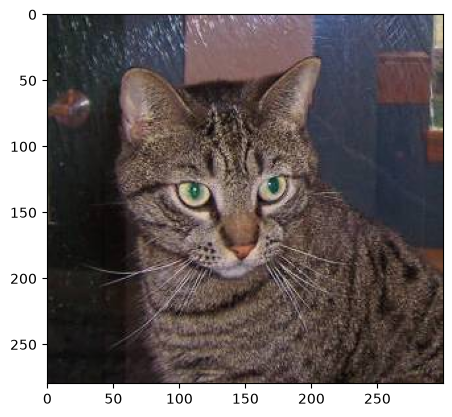

In [5]:
img = image.load_img("/Users/ansh/Desktop/CNN/Training/cats/cat.1.jpg")
plt.imshow(img)

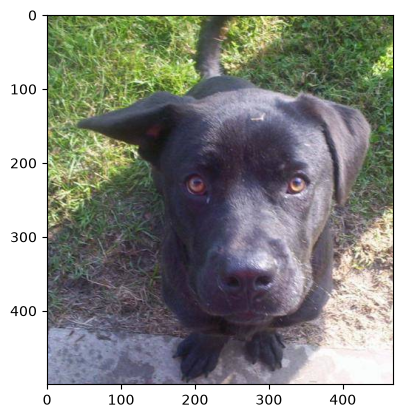

In [6]:
img = image.load_img(r"/Users/ansh/Desktop/CNN/Testing/dog.8.jpg" )
plt.imshow(img)

In [7]:
train = ImageDataGenerator(rescale= 1/255)
validation = ImageDataGenerator(rescale= 1/255)

In [8]:
tr_location = r"/Users/ansh/Desktop/CNN/Training"
val_location = r"/Users/ansh/Desktop/CNN/validation"

In [9]:
train_data = train.flow_from_directory(tr_location,
                                      target_size=(200,200),
                                      batch_size= 3,
                                      class_mode= "binary")
valid_data = validation.flow_from_directory(val_location,
                                      target_size=(200,200),
                                      batch_size= 3,
                                      class_mode= "binary")

Found 20 images belonging to 2 classes.
Found 9 images belonging to 2 classes.


In [10]:
train_data.class_indices

{'cats': 0, 'dogs': 1}

In [18]:
model = tf.keras.models.Sequential([

    tf.keras.layers.Conv2D(16,(3,3),activation="relu",input_shape=(200,200,3)),
    tf.keras.layers.MaxPool2D(2,2),

    tf.keras.layers.Conv2D(32,(3,3),activation="relu"),
    tf.keras.layers.MaxPool2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3), activation="relu"),
    tf.keras.layers.MaxPool2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(512,activation="relu"),

    tf.keras.layers.Dense(1,activation="sigmoid")])

In [19]:

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 198, 198, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 99, 99, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 97, 97, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 46, 46, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    17,334,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,358,881 (66.22 MB)

 Trainable params: 17,358,881 (66.22 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(loss = "binary_crossentropy", optimizer= RMSprop(learning_rate= 0.001),
             metrics=["accuracy"])

In [21]:
model.fit(train_data,steps_per_epoch=3, epochs= 50 , validation_data=valid_data)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.5000 - loss: 11.0635 - val_accuracy: 0.4444 - val_loss: 3.9781
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8889 - loss: 0.6619 - val_accuracy: 0.4444 - val_loss: 1.7578
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0000e+00 - loss: 2.6221 - val_accuracy: 0.5556 - val_loss: 3.6220
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3750 - loss: 3.1176 - val_accuracy: 0.4444 - val_loss: 1.5576
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.2222 - loss: 1.3455 - val_accuracy: 0.4444 - val_loss: 1.2364
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6667 - loss: 0.8101 - val_accuracy: 0.4444 - val_loss: 0.9322
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5000 - loss: 0.7225 - val_accuracy: 0.4444 - val_loss: 0.7600
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5556 - loss: 0.7143 - val_accuracy: 0.6667 - val_loss: 0

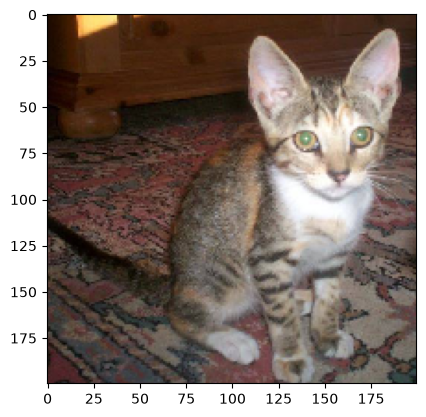

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
cat


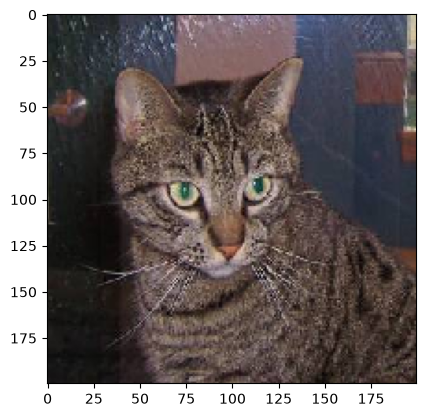

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
cat


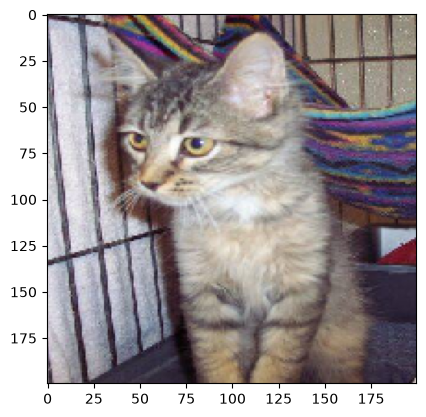

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
cat


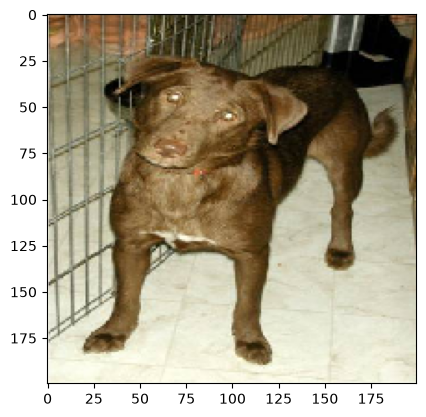

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
dog


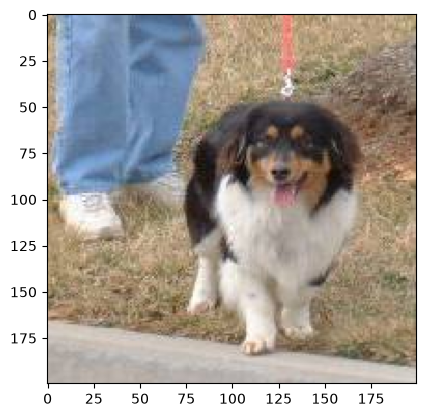

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
dog


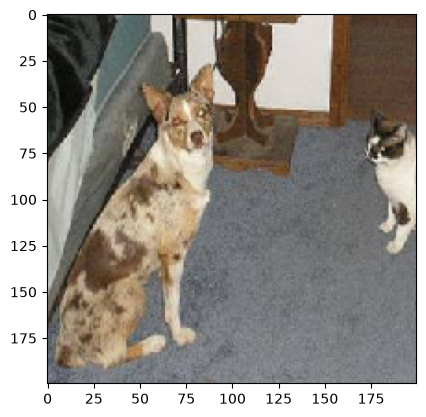

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
dog


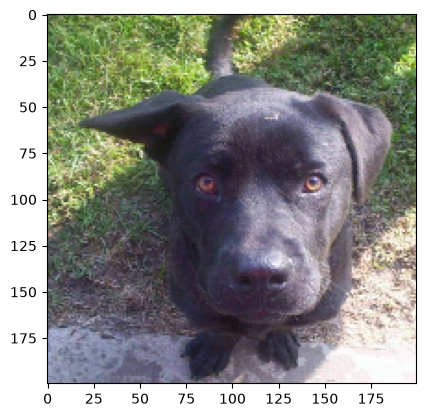

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
dog


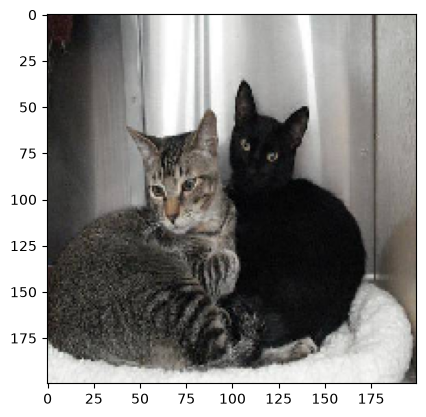

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
cat


In [22]:
path = r"/Users/ansh/Desktop/Bhupinder_Sandhu/CNN/Testing"
for i in os.listdir(path):
    img = image.load_img(path+"/"+i,target_size=(200,200))
    plt.imshow(img)
    plt.show()
    
    x = image.img_to_array(img)
    x = np.expand_dims(x,axis = 0)
    pic = np.vstack([x])
    val = model.predict(pic)
    if val==0:
        print("cat")
    else:
        print("dog")

In [16]:
model.save("cats_dogs_model.keras")

In [17]:
print(model.input_shape)
print(model.summary())

(None, 200, 200, 3)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,068 (250.27 KB)

 Trainable params: 32,033 (125.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 32,035 (125.14 KB)

None
